🔧 **Building and training an RNN model & Compare it with LSTM**


---



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.random import set_seed

set_seed(455)
np.random.seed(455)

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Mastercard_stock_history.csv to Mastercard_stock_history.csv


In [7]:
# Load data from a CSV file. Mastercard stock price data is loaded,
# with the Date column selected as the index and converted to a date.
dataset = pd.read_csv("Mastercard_stock_history.csv", index_col="Date", parse_dates=["Date"])
# Delete unimportant columns such as dividends and stock splits
dataset = dataset.drop(["Dividends", "Stock Splits"], axis=1)
# Display the first 5 rows of data:
print(dataset.head())


                Open      High       Low     Close     Volume
Date                                                         
2006-05-25  3.748967  4.283869  3.739664  4.279217  395343000
2006-05-26  4.307126  4.348058  4.103398  4.179680  103044000
2006-05-30  4.183400  4.184330  3.986184  4.093164   49898000
2006-05-31  4.125723  4.219679  4.125723  4.180608   30002000
2006-06-01  4.179678  4.474572  4.176887  4.419686   62344000


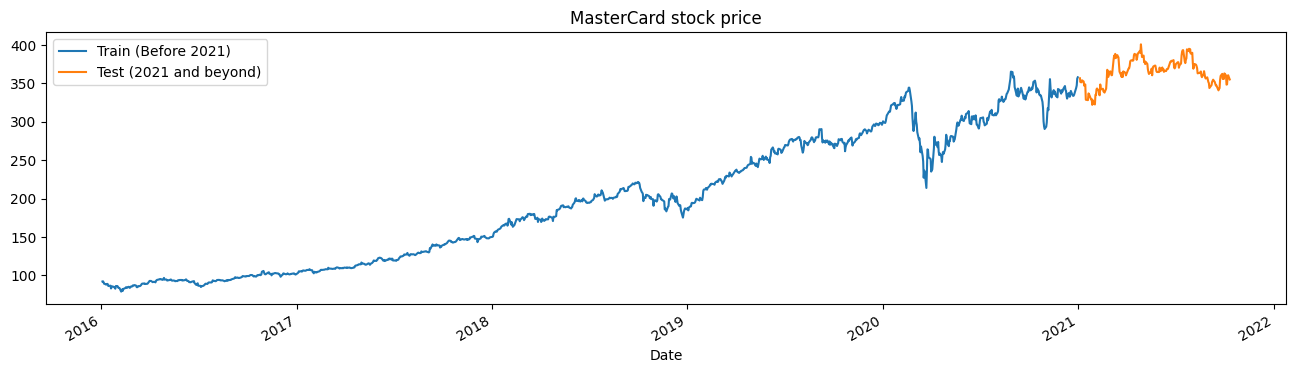

In [12]:
# Specify the start and end of the time period
tstart = 2016
tend = 2020

# train_test_splot function : plotting two sections of data =>
# The time period between tstart and tend
# The period following the year tend+1
def train_test_plot(dataset, tstart, tend):
  # Plots data for the period from 2016 to 2020
  dataset.loc[f'{tstart}':f'{tend}','High'].plot(figsize=(16, 4), legend=True)
  # Plots data from the year after 2020 (i.e. 2021 and beyond).
  dataset.loc[f'{tend+1}':,'High'].plot(figsize=(16, 4), legend=True)
  plt.legend([f'Train (Before {tend+1})', f'Test ({tend+1} and beyond)'])
  plt.title('MasterCard stock price')
  plt.show()

train_test_plot(dataset,tstart,tend)

In [13]:
def train_test_split(dataset, tstar, tend):
  train = dataset.loc[f'{tstart}':f'{tend}', 'High'].values
  test = dataset.loc[f'{tend+1}':, 'High'].values
  return train, test
training_set, test_set = train_test_split(dataset, tstart, tend)

In [14]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)


In [15]:
def split_sequence(sequence, n_steps):
  X,y = list(), list()
  for i in range(len(sequence)):
    end_ix = i + n_steps
    if end_ix > len(sequence)-1:
      break
    seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
    X.append(seq_x)
    y.append(seq_y)
  return np.array(X), np.array(y)

n_steps = 60
features = 1
# split into samples
X_train, y_train = split_sequence(training_set_scaled, n_steps)

🧱 Build an RNN model

In [16]:
model_rnn = Sequential()
# first RNN layer with 100 units (neurons), and it returns a sequence of values ​​(return_sequences=True) because after it in the second RNN layer
model_rnn.add(SimpleRNN(100, activation='tanh', input_shape=(n_steps, features), return_sequences=True))
# The second layer has 50 units, and ultimately gives the value we want to predict
model_rnn.add(SimpleRNN(50, activation='tanh'))
# A final layer gives only one output, which is the expected value of the stock price
model_rnn.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


⚙️ Assemble the model

In [17]:
model_rnn.compile(optimizer='adam', loss='mean_squared_error')
# optimizer='adam' → updating weights and improving the model

# loss='mean_squared_error'→ The MSE error function, which calculates the difference between the actual and predicted values

🏋️‍♂️ Model training

In [18]:
history_rnn = model_rnn.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0826
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0011
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 7.3381e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 7.5596e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.3380e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.0737e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 4.9876e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 4.6681e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 4.1066e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.7943e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.7070e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.6968e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.6838e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 3.5827e-04
Epoch 15/20
38/38 ━━━━━

In [20]:
dataset_total = dataset.loc[:,"High"]
inputs = dataset_total[len(dataset_total) - len(test_set) - n_steps :].values
inputs = inputs.reshape(-1, 1)
#scaling
inputs = sc.transform(inputs)

# Split into samples
X_test, y_test = split_sequence(inputs, n_steps)
# reshape
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], features)


**🔮 Predicting values ​​using test data**

In [21]:
y_pred_rnn = model_rnn.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [25]:
def plot_predictions(test, predicted):
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title("MasterCard Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("MasterCard Stock Price")
    plt.legend()
    plt.show()


def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))

**📏 Calculate the model error**

The root mean squared error is 0.02.


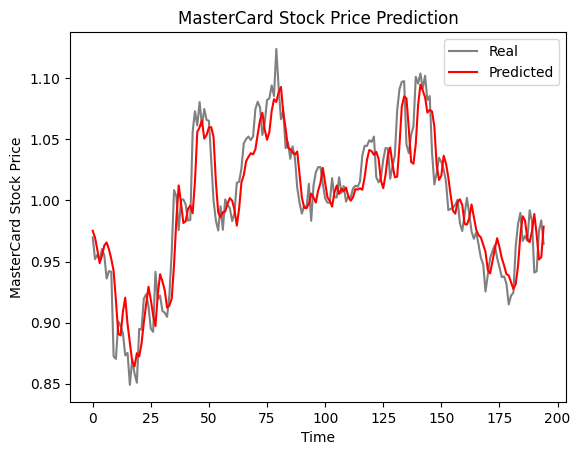

In [26]:
return_rmse(y_test, y_pred_rnn)
plot_predictions(y_test, y_pred_rnn)

RNN Graph

✅  RNN Model

📉 الخطأ (RMSE): 0.02


---
LSTM Graph

✅ LSTM Model

📉 (RMSE): 0.06


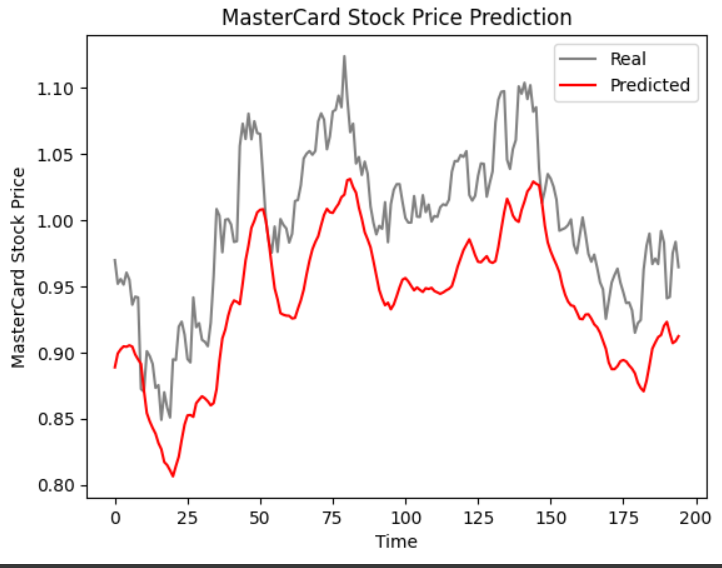



---
RNN Model

The predictions are much more accurate and capture the real stock price pattern very well

LSTM Model

The model’s predictions follow the general trend of the actual stock price but show noticeable differences and delays, especially during sharp movements



📌 Conclusion:

Although LSTM models are generally stronger in learning temporal patterns, in this specific case, the RNN model performed better — both in terms of lower error and better visual alignment with actual prices. This may be due to:

Simplicity of the data,

Short training duration,

Or the LSTM model needing further tuning.

